In [1]:
import pandas as pd
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import semopy 
from stepmix.stepmix import StepMix

In [2]:
df = pd.read_csv('C:/Users/edins/OneDrive/Escritorio/machine learning/data/junaeb2.csv')
df = df.dropna()
df

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,1,1,1,4.0,0,8.0,8,-1
6,1,91,2.75,1,1,1,1,1,2,2,...,3,3,3,2,2,2.0,1,20.0,19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41849,0,78,1.63,1,1,1,3,1,2,2,...,2,2,2,1,1,2.0,1,13.0,13,-1
41850,1,79,2.57,1,1,1,1,2,2,1,...,1,3,2,1,4,3.0,1,18.0,19,0
41851,0,78,2.12,1,1,1,1,1,1,1,...,1,3,1,1,1,3.0,1,13.0,9,1
41852,1,78,-0.43,1,1,1,1,1,1,2,...,1,2,1,1,2,2.0,1,17.0,15,1


In [3]:
df.dtypes

sexo            int64
edad            int64
imce          float64
vive_padre      int64
vive_madre      int64
sk1             int64
sk2             int64
sk3             int64
sk4             int64
sk5             int64
sk6             int64
sk7             int64
sk8             int64
sk9             int64
sk10            int64
sk11            int64
sk12            int64
sk13            int64
act_fisica    float64
area            int64
educm         float64
educp           int64
madre_work      int64
dtype: object

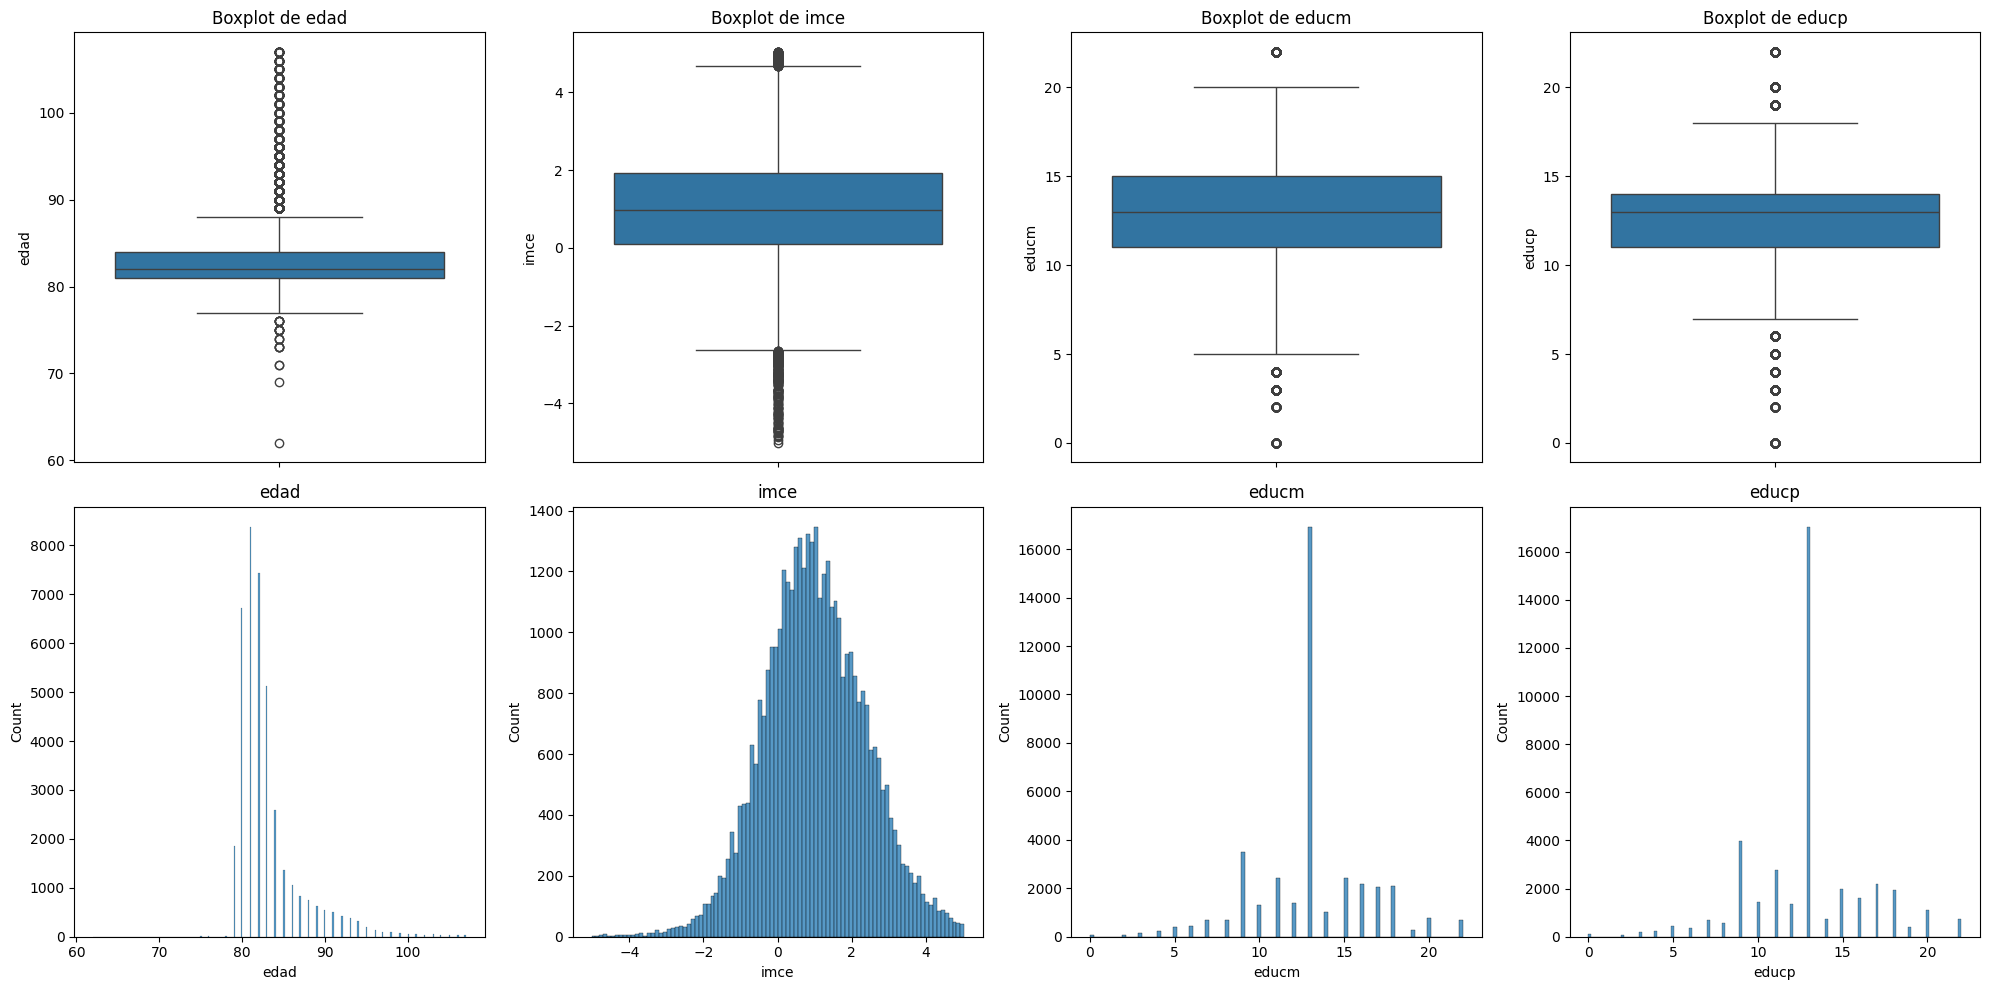

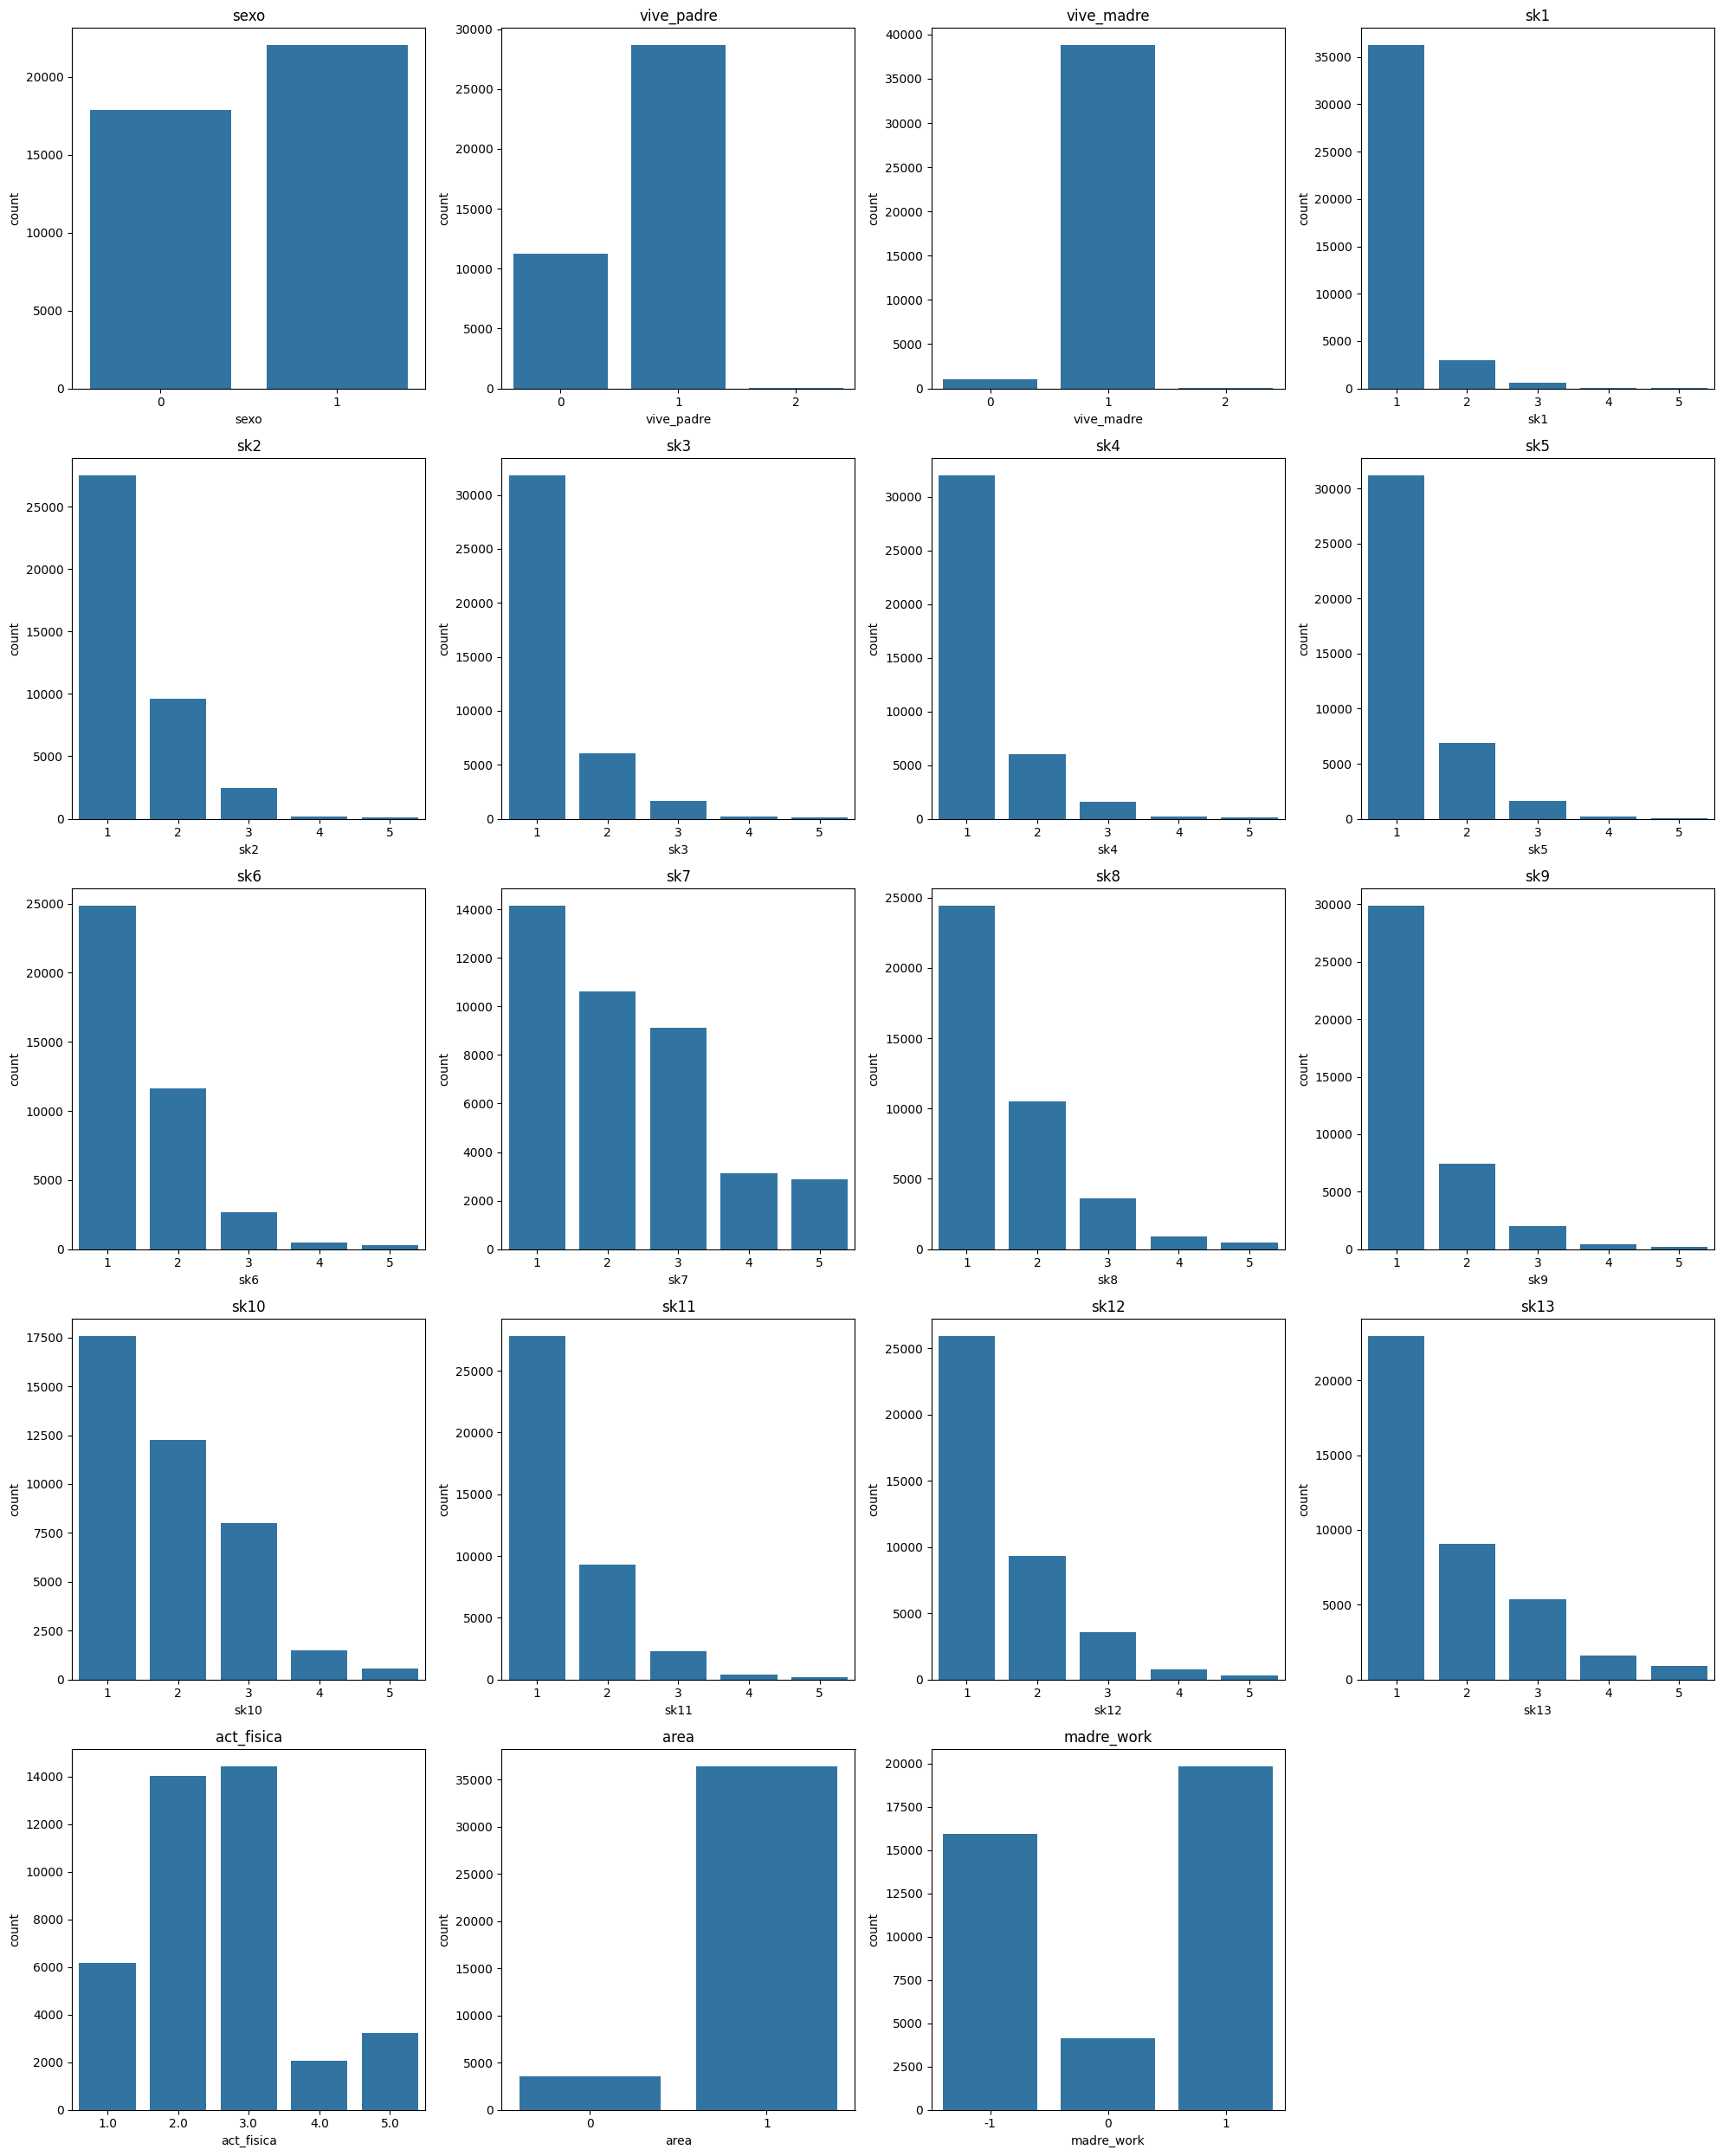

In [4]:
col_box = ['edad', 'imce', 'educm', 'educp']
n = len(col_box)

fig, axes = plt.subplots(nrows=2, ncols=n, figsize=(20, 10))  

for i, col in enumerate(col_box):
 
    sns.boxplot(y=df[col].dropna(), ax=axes[0, i])
    axes[0, i].set_title(f'Boxplot de {col}')
    axes[0, i].set_ylabel(col)
    
    sns.histplot(df[col].dropna(), ax=axes[1, i], kde=False)
    axes[1, i].set_title(f'{col}')
    axes[1, i].set_xlabel(col)

plt.tight_layout()
plt.show()

col_bar = [col for col in df.columns if col not in col_box]

fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten() 

for i, col in enumerate(col_bar):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)

# Eliminar ejes vacíos si hay
for j in range(len(col_bar), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

2. EFA

In [60]:
fa = FactorAnalyzer(rotation='oblimin').fit(df1)
np.set_printoptions(suppress=True, precision=6)
fa.loadings_

c:\Users\edins\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([[ 0.019582,  0.591841, -0.021555],
       [-0.002865,  0.502948,  0.222328],
       [ 0.027641,  0.638366, -0.028415],
       [ 0.006896,  0.730682, -0.013931],
       [-0.033435,  0.023475,  0.772074],
       [ 0.072927,  0.072227,  0.469603],
       [ 0.041492,  0.038748,  0.129864],
       [ 0.214352, -0.079379,  0.46402 ],
       [ 0.502243,  0.079241,  0.052746],
       [ 0.607628, -0.029821, -0.023511],
       [ 0.697418,  0.036714,  0.009946],
       [ 0.5724  , -0.030446, -0.000008],
       [ 0.530523,  0.017536, -0.011748]])

Las variables sk1, sk2, sk3 y sk4 están mayormente asociadas al factor 2, mientras que las variables sk5, sk6 y sk8 se encuentran asociadas 
al factor 3. Por último, las variables desde sk9 hasta sk13 están relacionadas al factor 1. Los valores cercanos a 0 para la variable sk7 indican que no se encuentra mayormente asociada a ningún factor


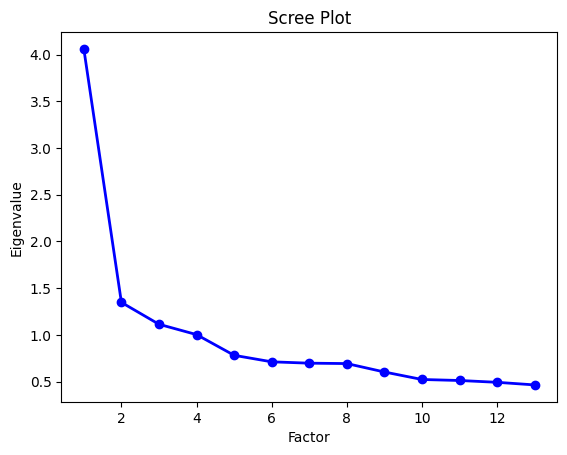

In [13]:
values = np.arange(1,14)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

3.

c:\Users\edins\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


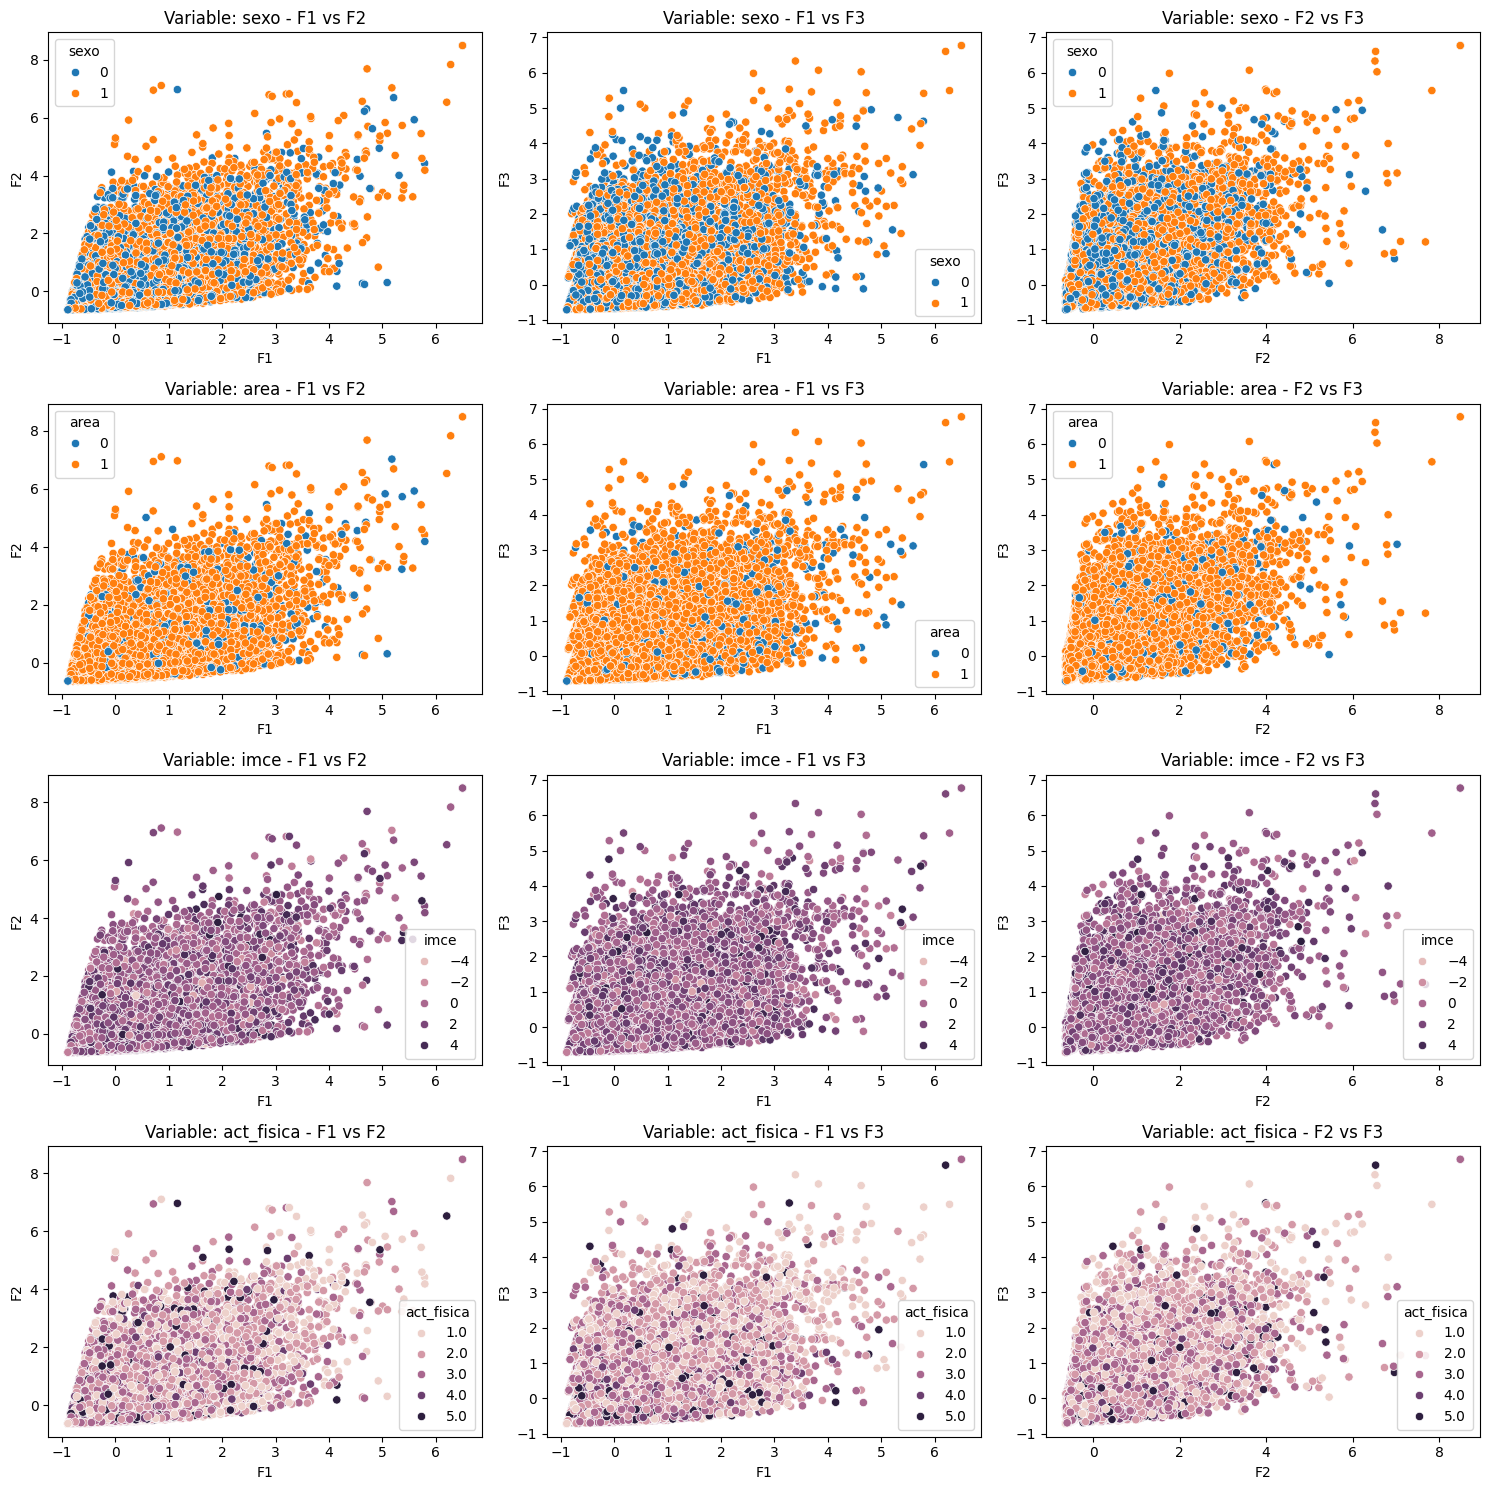

In [61]:
factores = fa.transform(df1)
dfa = df
dfa['F1'] = factores[:,0]
dfa['F2'] = factores[:,1]
dfa['F3'] = factores[:,2]

fig, axes = plt.subplots(4, 3, figsize=(15, 15))  

hues = ['sexo', 'area', 'imce', 'act_fisica']
xy_pairs = [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]

for row in range(4):
    for col in range(3):
        ax = axes[row, col]
        hue_var = hues[row]
        x_var, y_var = xy_pairs[col]
        
        sns.scatterplot(data=dfa, x=x_var, y=y_var, hue=hue_var, ax=ax)
        
        ax.set_title(f'Variable: {hue_var} - {x_var} vs {y_var}')
        ax.set_xlabel(x_var)
        ax.set_ylabel(y_var)

plt.tight_layout()
plt.show()

Como se puede observar, no se ve ninguna relación clara entre los componentes principales y las variables sexo, area, imce y act_fisica

4. CFA

In [ ]:
df_sk=df1[['sk1','sk2','sk3','sk4','sk5','sk6','sk8','sk9','sk10','sk11','sk12','sk13']]

mod = """
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13         #Interes y curiosidad
eta2 =~ sk1 + sk2 + sk3 + sk4                   #Expresión de emociones
eta3 =~ sk5 + sk6 + sk8                         #Interacción con otros
"""
model = semopy.Model(mod);
out = model.fit(df_sk);
print(out);

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.148
Number of iterations: 38
Params: 1.326 1.234 1.087 1.285 1.877 1.639 1.810 1.017 1.142 0.161 0.054 0.096 0.051 0.060 0.168 0.098 0.620 0.210 0.450 0.726 0.247 0.203 0.167 0.155 0.373 0.484 0.287


In [63]:
estimates = model.inspect()
print(estimates)


    lval  op  rval  Estimate  Std. Err     z-value p-value
0    sk9   ~  eta1  1.000000         -           -       -
1   sk10   ~  eta1  1.325516  0.015671   84.583493     0.0
2   sk11   ~  eta1  1.234209  0.012458   99.069536     0.0
3   sk12   ~  eta1  1.087471  0.013103   82.991547     0.0
4   sk13   ~  eta1  1.285096  0.016089   79.876675     0.0
5    sk1   ~  eta2  1.000000         -           -       -
6    sk2   ~  eta2  1.877294  0.020371   92.153655     0.0
7    sk3   ~  eta2  1.639420  0.018029   90.934771     0.0
8    sk4   ~  eta2  1.810308  0.018777   96.410991     0.0
9    sk5   ~  eta3  1.000000         -           -       -
10   sk6   ~  eta3  1.017412   0.01216    83.67048     0.0
11   sk8   ~  eta3  1.142366   0.01374   83.141749     0.0
12  eta1  ~~  eta1  0.161036  0.002781   57.899711     0.0
13  eta1  ~~  eta2  0.054415  0.000875   62.215041     0.0
14  eta1  ~~  eta3  0.096261  0.001508   63.844859     0.0
15  eta2  ~~  eta2  0.051030  0.000902   56.583474     0

Todas las cargas son significativas para sus factores (p<0.05). En especial, las variables sk2 y sk4 son las que mas carga muestran en el Factor 2, lo cual representa su alta relación con la expresión de emociones

In [56]:
#matriz de correlaciones
from factor_analyzer import (ConfirmatoryFactorAnalyzer, ModelSpecificationParser)
model_dict = {"F2": ["sk1", "sk2", "sk3", "sk4"],
              "F1": ["sk5", "sk6", "sk8"],
              "F3": ["sk9", "sk10", "sk11", "sk12", "sk13"]}
model_spec = ModelSpecificationParser.parse_model_specification_from_dict(df_sk, model_dict)
cfa = ConfirmatoryFactorAnalyzer(model_spec, disp=False).fit(df_sk)
cfa.factor_varcovs_

c:\Users\edins\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([[1.      , 0.647804, 0.600301],
       [0.647804, 1.      , 0.585491],
       [0.600301, 0.585491, 1.      ]])

Todas las correlaciones son mayores a 0.5, lo cual indica que todos los factores estan moderadamente correlacionados entre si. Esto es lógico tomando en cuenta que todas las variables representan conductas 'positivas'.

5. Stepmix

In [57]:
df3=df[['sk1','sk2','sk3','sk4','sk5','sk6','sk8','sk9','sk10','sk11','sk12','sk13','imce']]
model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)
model.fit(df3)
df['pred']=model.predict(df3)

AttributeError: 'StepMix' object has no attribute '_validate_data'

6. SEM

In [ ]:
mod_cf = '''
#Measurement
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13            #Interes y curiosidad
eta2 =~ sk1 + sk2 + sk3 + sk4                     #Expresión de emociones
eta3 =~ sk5 + sk6 + sk8                           #Interacción con otros


#Structural
imce ~ eta1 + eta2 + eta3 + sexo + imce + area + madre_work + act_fisica
'''

model_cfa = semopy.Model(mod_cf);
out = model_cfa.fit(df);
print(out)


Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.303
Number of iterations: 44
Params: 1.322 1.232 1.085 1.282 1.883 1.646 1.818 1.017 1.143 -0.007 -0.262 0.184 0.119 0.197 -0.135 0.024 -0.024 0.162 0.054 0.096 0.051 0.060 0.168 1.219 0.098 0.620 0.210 0.450 0.726 0.247 0.203 0.167 0.155 0.373 0.483 0.287


In [20]:
semopy.calc_stats(model_cfa)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,117,140,12069.181411,0.0,117112.795319,0.897821,0.896944,0.876685,0.896944,0.877734,0.050601,71.394998,380.781931,0.302501


Los valores de CFI y TLI son relativamente altos (~0.9), lo cual indica que se ajustan bien al modelo. Por otro lado, el valor de RMSEA es cercano a 0.05, lo cual también sugiere un buen ajuste

In [21]:
model_cfa.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,imce,~,eta1,-0.006919,-0.002017,0.024234,-0.285521,0.775245
1,imce,~,eta2,-0.261755,-0.042733,0.047789,-5.477258,0.0
2,imce,~,eta3,0.183749,0.054555,0.027352,6.717884,0.0
3,imce,~,sexo,0.118831,0.042838,0.011126,10.680941,0.0
4,imce,~,imce,0.196633,0.196633,0.0031,63.434917,0.0
5,imce,~,area,-0.134828,-0.027695,0.019632,-6.867838,0.0
6,imce,~,madre_work,0.024379,0.016643,0.005907,4.126902,0.000037
7,imce,~,act_fisica,-0.023994,-0.018603,0.005191,-4.622518,0.000004
8,sk9,~,eta1,1.000000,0.600182,-,-,-
9,sk10,~,eta1,1.321605,0.559241,0.01562,84.607937,0.0


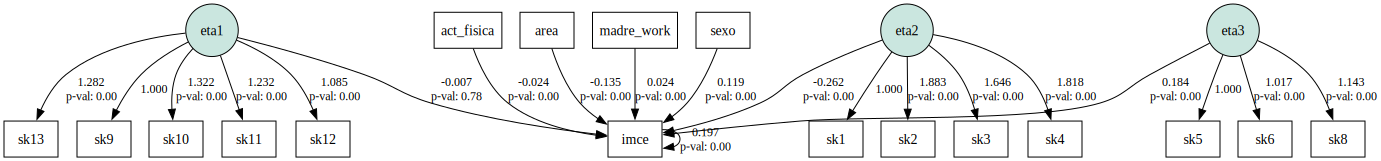

In [22]:
semopy.semplot(model_cfa, "semmodel.png")